# PSMA PET SUV conversion + per-lesion SUVmax

Patient `data/psma/p-001` (68Ga-PSMA whole-body PET/CT).

Pipeline:
1. De-duplicate the CT and PET DICOM exports (each file is present twice on disk under different filenames but identical `SOPInstanceUID` — confirmed below).
2. Read the TOF PET series into a `torch` tensor and convert raw counts to SUVbw voxel-by-voxel, reusing the IBSI-SUV-compliant per-slice factor computation from `scripts/psma_suvconv.py`.
3. For each of the three lesion RTSTRUCT files (`ANTERIOR_PROSTATE`, `L_POSTERIOR_PROSTATE`, `R_POSTERIOR_PROSTATE`, each contoured on the CT grid), map the lesion mask into PET voxel space via the shared patient physical (mm) coordinate frame and report SUVmax.

In [2]:
import glob
import os
import shutil
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
import SimpleITK as sitk
import torch
from rt_utils import RTStructBuilder, image_helper

sys.path.append(str(Path('..').resolve() / 'scripts'))
from psma_suvconv import compute_suv_factor_for_slice
from lesion_metrics import sitk_affine
from closest_anatomy import physical_points_to_indices

PATIENT_DIR = Path('../data/psma/p-001')
OUTPUT_DIR = Path('../outputs/psma/p-001')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ct_dir = PATIENT_DIR / 'CT_WB_2_0_B26F_3_2MM_0004'
pet_dir = PATIENT_DIR / 'TOF_PET_WB_CORRECTED_0003'

lesion_rtstruct_files = {
    'anterior_prostate': next((PATIENT_DIR / 'ANTERIOR_PROSTATE_0001').glob('*.IMA')),
    'l_posterior_prostate': next((PATIENT_DIR / 'L_POSTERIOR_PROSTATE_0001').glob('*.IMA')),
    'r_posterior_prostate': next((PATIENT_DIR / 'R_POSTERIOR_PROSTATE_0001').glob('*.IMA')),
}
lesion_rtstruct_files

{'anterior_prostate': WindowsPath('../data/psma/p-001/ANTERIOR_PROSTATE_0001/ABACHI_GHAREH_AGHAJ_HASAN.RTSTRUCT.PET_CT_68GA_PSMA_WHOLEBODY_(ADULT).0001.0000.2023.08.15.15.28.51.125000.613985578.IMA'),
 'l_posterior_prostate': WindowsPath('../data/psma/p-001/L_POSTERIOR_PROSTATE_0001/ABACHI_GHAREH_AGHAJ_HASAN.RTSTRUCT.PET_CT_68GA_PSMA_WHOLEBODY_(ADULT).0001.0000.2023.08.15.15.28.51.125000.614075001.IMA'),
 'r_posterior_prostate': WindowsPath('../data/psma/p-001/R_POSTERIOR_PROSTATE_0001/ABACHI_GHAREH_AGHAJ_HASAN.RTSTRUCT.PET_CT_68GA_PSMA_WHOLEBODY_(ADULT).0001.0000.2023.08.15.15.28.51.125000.614011189.IMA')}

## 1. De-duplicate the DICOM exports

Both the CT and PET folders contain every slice twice (same `SOPInstanceUID`, two filenames —
an export artifact). Feeding the raw folders to `SimpleITK`/`rt_utils` makes them treat the
duplicates as extra slices at the same physical position (`ImageSeriesReader` warns about
"non uniform sampling"), which corrupts the geometry. Keep one copy per `SOPInstanceUID`.

In [3]:
def dedup_dicom_dir(src_dir: Path, dst_dir: Path) -> Path:
    """Copy one file per unique SOPInstanceUID from src_dir into dst_dir."""
    dst_dir.mkdir(parents=True, exist_ok=True)
    seen = set()
    for f in sorted(src_dir.glob('*.IMA')):
        uid = pydicom.dcmread(f, stop_before_pixels=True).SOPInstanceUID
        if uid in seen:
            continue
        seen.add(uid)
        dst = dst_dir / f.name
        if not dst.exists():
            shutil.copy2(f, dst)
    return dst_dir


ct_dedup_dir = dedup_dicom_dir(ct_dir, OUTPUT_DIR / 'ct_dedup')
pet_dedup_dir = dedup_dicom_dir(pet_dir, OUTPUT_DIR / 'pet_dedup')

print(f'CT:  {len(list(ct_dir.glob("*.IMA")))} files on disk -> {len(list(ct_dedup_dir.glob("*.IMA")))} unique slices')
print(f'PET: {len(list(pet_dir.glob("*.IMA")))} files on disk -> {len(list(pet_dedup_dir.glob("*.IMA")))} unique slices')

CT:  1934 files on disk -> 967 unique slices
PET: 646 files on disk -> 323 unique slices


## 2. Read the TOF PET series into a torch tensor and convert to SUV

`SimpleITK.ImageSeriesReader.GetGDCMSeriesFileNames` gives the geometrically-sorted file
order (handles slice ordering / spacing properly). We read pixels for that exact file order
with `pydicom`, apply the per-slice rescale (`m * pixel + b`) and then the per-slice SUV
factor from `compute_suv_factor_for_slice` (`scripts/psma_suvconv.py` — IBSI-SUV compliant:
correct decay-corrected dose, `DecayCorrection=START` reference time, etc.), all as a stacked
`torch.float32` tensor shaped `(Z, Y, X)` — the same axis order `SimpleITK`/`numpy` use.

In [4]:
# Geometry (spacing / origin / direction) + the authoritative, geometrically-sorted file order
geo_reader = sitk.ImageSeriesReader()
pet_filenames = geo_reader.GetGDCMSeriesFileNames(str(pet_dedup_dir))
geo_reader.SetFileNames(pet_filenames)
pet_geom_img = geo_reader.Execute()

print('PET size (X, Y, Z):', pet_geom_img.GetSize())
print('PET spacing (mm):', pet_geom_img.GetSpacing())

first_dcm = pydicom.dcmread(pet_filenames[0])

raw_slices = []
suv_slices = []
label = None
for fname in pet_filenames:
    dcm = pydicom.dcmread(fname)
    pixels = torch.from_numpy(dcm.pixel_array.astype(np.float32))

    m = float(getattr(dcm, 'RescaleSlope', 1.0))
    b = float(getattr(dcm, 'RescaleIntercept', 0.0))
    physical = m * pixels + b  # Bq/mL

    suv_factor, label = compute_suv_factor_for_slice(dcm, first_dcm)
    raw_slices.append(pixels)
    suv_slices.append(physical * suv_factor)

pet_raw_tensor = torch.stack(raw_slices, dim=0)   # (Z, Y, X) raw pixel counts
pet_suv_tensor = torch.stack(suv_slices, dim=0)   # (Z, Y, X) SUVbw

print(f'Conversion mode: {label}')
print('pet_suv_tensor shape:', tuple(pet_suv_tensor.shape), 'dtype:', pet_suv_tensor.dtype)
print(f'SUV min/mean/max: {pet_suv_tensor.min():.3f} / {pet_suv_tensor.mean():.3f} / {pet_suv_tensor.max():.3f}')

PET size (X, Y, Z): (200, 200, 323)
PET spacing (mm): (4.07283, 4.07283, 3.0)
Conversion mode: BQML/DC=START
pet_suv_tensor shape: (323, 200, 200) dtype: torch.float32
SUV min/mean/max: 0.000 / 0.093 / 97.751


## 3. Per-lesion SUVmax

Each lesion RTSTRUCT is contoured against the **CT** series, not PET (`ReferencedSeriesInstanceUID`
matches the CT). A lesion file can hold more than one ROI (contour pieces of the same lesion) —
union them into one mask, same convention as `rtstruct_to_nifti_mask` in `psma_suvconv.py`.

To get SUV values for a CT-space mask: turn its voxel indices into patient-space millimeters
(`image_helper.apply_transformation_to_3d_points`, same pixel-to-patient matrix machinery
already used in `scripts/closest_anatomy.py`), then invert the PET affine to land on PET voxel
indices, and index straight into `pet_suv_tensor`. No image resampling needed — SUVmax is a
per-voxel max, so nearest-neighbour point sampling is exact.

In [5]:
pet_affine = sitk_affine(pet_geom_img)          # PET voxel (x, y, z) -> patient mm
pet_shape_xyz = np.array(pet_geom_img.GetSize())  # (X, Y, Z), matches pet_suv_tensor.shape[::-1]

results = []
for lesion_name, rtstruct_path in lesion_rtstruct_files.items():
    rtstruct = RTStructBuilder.create_from(dicom_series_path=str(ct_dedup_dir), rt_struct_path=str(rtstruct_path))
    roi_names = rtstruct.get_roi_names()
    masks = [rtstruct.get_roi_mask_by_name(r) for r in roi_names]
    combined_mask = np.logical_or.reduce(masks)  # CT grid, (X, Y, Z)

    pixel_to_patient = image_helper.get_pixel_to_patient_transformation_matrix(rtstruct.series_data)
    voxel_idx = np.argwhere(combined_mask).astype(float)
    physical_pts = image_helper.apply_transformation_to_3d_points(voxel_idx, pixel_to_patient)

    pet_idx = np.rint(physical_points_to_indices(physical_pts, pet_affine)).astype(int)
    in_bounds = np.all((pet_idx >= 0) & (pet_idx < pet_shape_xyz), axis=1)

    ix, iy, iz = pet_idx[in_bounds, 0], pet_idx[in_bounds, 1], pet_idx[in_bounds, 2]
    suv_values = pet_suv_tensor[torch.from_numpy(iz).long(), torch.from_numpy(iy).long(), torch.from_numpy(ix).long()]

    results.append({
        'lesion': lesion_name,
        'roi_names': roi_names,
        'n_ct_voxels': int(combined_mask.sum()),
        'n_pet_samples': int(in_bounds.sum()),
        'n_dropped_outside_pet_fov': int((~in_bounds).sum()),
        'suv_max': suv_values.max().item(),
        'suv_mean': suv_values.mean().item(),
    })

report_df = pd.DataFrame(results)
report_df.to_csv(OUTPUT_DIR / 'lesion_suvmax.csv', index=False)
report_df

,lesion,roi_names,n_ct_voxels,n_pet_samples,n_dropped_outside_pet_fov,suv_max,suv_mean
0,anterior_prostate,[1],7620,7620,0,21.297398,5.858262
1,l_posterior_prostate,"[3, 2, 1]",32523,32523,0,21.297398,1.959056
2,r_posterior_prostate,"[2, 1]",30335,30335,0,21.297398,2.056520


In [6]:
print('SUVmax per lesion:')
for _, row in report_df.iterrows():
    print(f"  {row['lesion']:<22} SUVmax = {row['suv_max']:.2f}   (SUVmean = {row['suv_mean']:.2f}, {row['n_pet_samples']} PET samples)")

SUVmax per lesion:
  anterior_prostate      SUVmax = 21.30   (SUVmean = 5.86, 7620 PET samples)
  l_posterior_prostate   SUVmax = 21.30   (SUVmean = 1.96, 32523 PET samples)
  r_posterior_prostate   SUVmax = 21.30   (SUVmean = 2.06, 30335 PET samples)


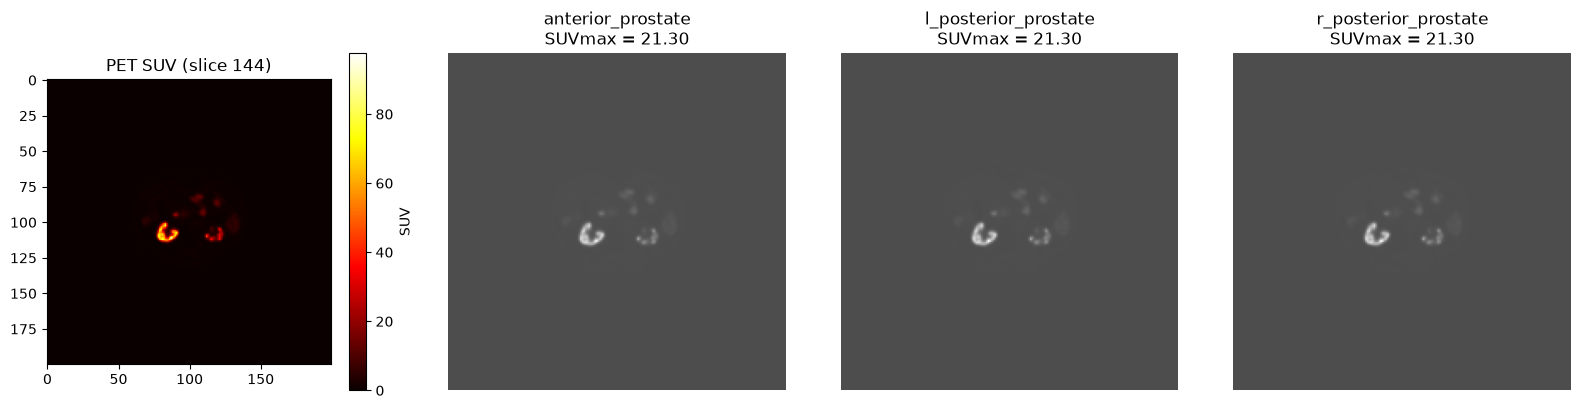

In [7]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# visualize the SUVmax locations on the PET volume
import matplotlib.pyplot as plt

pet_suv_np = pet_suv_tensor.numpy()

# Find the slice with maximum SUV
max_suv_slice = pet_suv_np.max(axis=(1, 2)).argmax()

fig, axes = plt.subplots(1, len(lesion_rtstruct_files) + 1, figsize=(16, 4))

# Plot PET slice with max SUV
im = axes[0].imshow(pet_suv_np[max_suv_slice], cmap='hot')
axes[0].set_title(f'PET SUV (slice {max_suv_slice})')
plt.colorbar(im, ax=axes[0], label='SUV')

# Overlay each lesion mask on PET
for idx, (lesion_name, rtstruct_path) in enumerate(lesion_rtstruct_files.items()):
  rtstruct = RTStructBuilder.create_from(dicom_series_path=str(ct_dedup_dir), rt_struct_path=str(rtstruct_path))
  roi_names = rtstruct.get_roi_names()
  masks = [rtstruct.get_roi_mask_by_name(r) for r in roi_names]
  combined_mask = np.logical_or.reduce(masks)
  
  axes[idx + 1].imshow(pet_suv_np[max_suv_slice], cmap='gray', alpha=0.7)
  axes[idx + 1].set_title(f'{lesion_name}\nSUVmax = {report_df[report_df["lesion"] == lesion_name]["suv_max"].values[0]:.2f}')
  axes[idx + 1].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'suv_visualization.png', dpi=150, bbox_inches='tight')
plt.show()



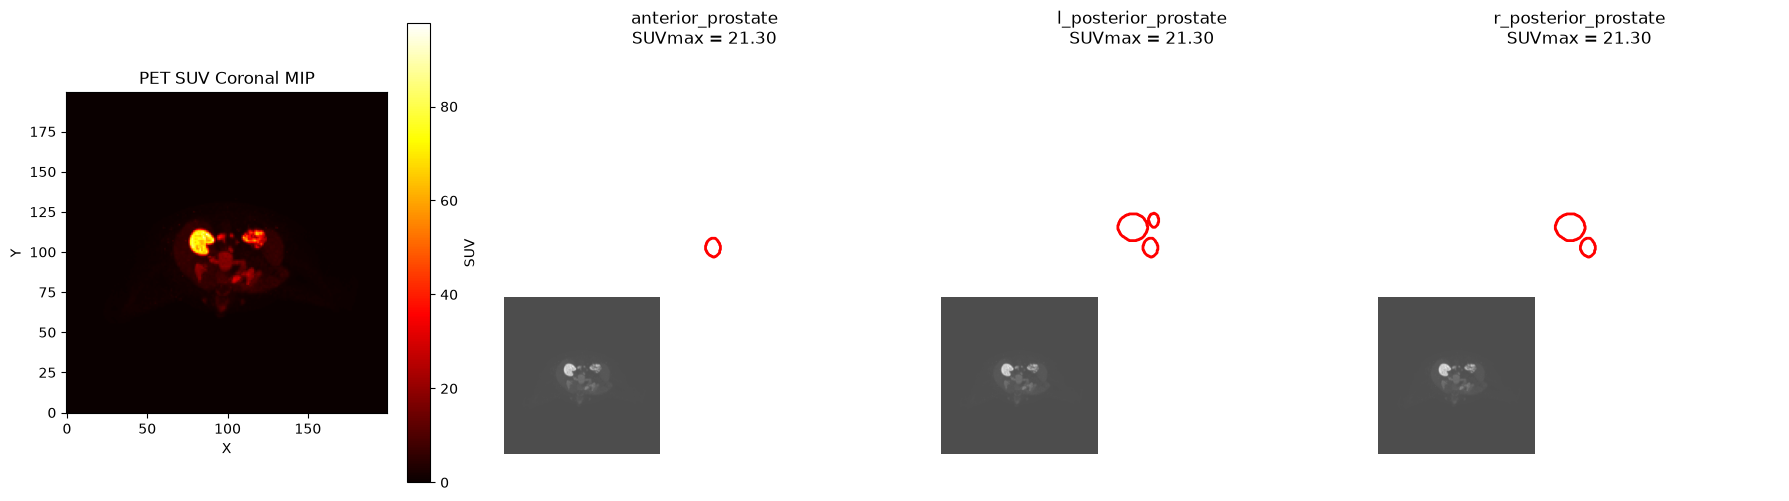

In [8]:
# Create a coronal maximum intensity projection (MIP) with lesion overlays
coronal_mip = pet_suv_np.max(axis=0)  # Project along Z axis

fig, axes = plt.subplots(1, len(lesion_rtstruct_files) + 1, figsize=(18, 5))

# Plot coronal MIP
im = axes[0].imshow(coronal_mip, cmap='hot', origin='lower')
axes[0].set_title('PET SUV Coronal MIP')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
plt.colorbar(im, ax=axes[0], label='SUV')

# Overlay each lesion mask on coronal MIP
for idx, (lesion_name, rtstruct_path) in enumerate(lesion_rtstruct_files.items()):
  rtstruct = RTStructBuilder.create_from(dicom_series_path=str(ct_dedup_dir), rt_struct_path=str(rtstruct_path))
  roi_names = rtstruct.get_roi_names()
  masks = [rtstruct.get_roi_mask_by_name(r) for r in roi_names]
  combined_mask = np.logical_or.reduce(masks)
  
  # Project mask along Z axis
  mask_coronal_mip = combined_mask.max(axis=2)
  
  axes[idx + 1].imshow(coronal_mip, cmap='gray', alpha=0.7, origin='lower')
  axes[idx + 1].contour(mask_coronal_mip, colors='red', linewidths=2, origin='lower')
  axes[idx + 1].set_title(f'{lesion_name}\nSUVmax = {report_df[report_df["lesion"] == lesion_name]["suv_max"].values[0]:.2f}')
  axes[idx + 1].set_xlabel('X')
  axes[idx + 1].set_ylabel('Y')
  axes[idx + 1].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lesions_coronal_mip.png', dpi=150, bbox_inches='tight')
plt.show()